<a href="https://colab.research.google.com/github/halimAhtasham/Network-_Intrusion_Detection---All_In_One/blob/main/ROSIDS23_Testing_Multiple_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
from sklearn.metrics._plot.confusion_matrix import ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    recall_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = ("/content/drive/MyDrive/Datasets/ROSIDS23.csv")

df  = pd.read_csv(DATASET_PATH)

# **Dataset Overview**

In [4]:
print(df.shape)
print(df.columns.tolist())

(136681, 84)
['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd By

In [5]:
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.3.4-192.168.3.6-11311-60792-6,192.168.3.6,60792,192.168.3.4,11311,6,07/07/2023 02:10:23 PM,6260,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,192.168.3.4-192.168.3.6-11311-60794-6,192.168.3.6,60794,192.168.3.4,11311,6,07/07/2023 02:10:23 PM,5903,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,192.168.3.4-192.168.3.6-11311-39922-6,192.168.3.6,39922,192.168.3.4,11311,6,07/07/2023 02:10:32 PM,4523,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,192.168.3.4-192.168.3.6-11311-55266-6,192.168.3.6,55266,192.168.3.4,11311,6,07/07/2023 02:11:11 PM,5191,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,192.168.3.6-192.168.3.7-43770-11111-6,192.168.3.7,11111,192.168.3.6,43770,6,07/07/2023 02:10:03 PM,72625778,2200,2212,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [6]:
df.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE 

In [7]:
df.dtypes

,0
Flow ID,object
Src IP,object
Src Port,int64
Dst IP,object
Dst Port,int64
...,...
Idle Mean,float64
Idle Std,float64
Idle Max,float64
Idle Min,float64


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

,0
Flow ID,0
Src IP,0
Src Port,0
Dst IP,0
Dst Port,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [10]:
df["Label"].value_counts()

,count
Label,
Benign,62511
DoS,31000
Subflood,30064
UnauthPub,7817
UnauthSub,5289


In [11]:
df["Label"].value_counts(normalize=True)

,proportion
Label,
Benign,0.457350
DoS,0.226805
Subflood,0.219957
UnauthPub,0.057192
UnauthSub,0.038696


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Src Port,136681.0,3.539043e+04,1.756249e+04,0.0,11311.0,38984.0,49178.0,6.553500e+04
Dst Port,136681.0,2.792530e+04,2.060046e+04,0.0,11311.0,35222.0,44930.0,6.541800e+04
Protocol,136681.0,6.065203e+00,9.652164e-01,0.0,6.0,6.0,6.0,1.700000e+01
Flow Duration,136681.0,3.093967e+07,3.490355e+07,0.0,4123.0,508341.0,58780722.0,1.200000e+08
Tot Fwd Pkts,136681.0,5.930385e+02,5.018832e+03,0.0,1.0,5.0,33.0,1.192570e+05
...,...,...,...,...,...,...,...,...
Active Min,136681.0,2.777034e+06,8.853524e+06,0.0,0.0,0.0,268.0,1.129778e+08
Idle Mean,136681.0,6.463119e+06,1.596497e+07,0.0,0.0,0.0,5525405.0,1.196444e+08
Idle Std,136681.0,1.126476e+06,4.999828e+06,0.0,0.0,0.0,0.0,4.755196e+07
Idle Max,136681.0,7.469949e+06,1.776872e+07,0.0,0.0,0.0,5744825.0,1.196444e+08


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136681 entries, 0 to 136680
Data columns (total 84 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow ID            136681 non-null  object 
 1   Src IP             136681 non-null  object 
 2   Src Port           136681 non-null  int64  
 3   Dst IP             136681 non-null  object 
 4   Dst Port           136681 non-null  int64  
 5   Protocol           136681 non-null  int64  
 6   Timestamp          136681 non-null  object 
 7   Flow Duration      136681 non-null  int64  
 8   Tot Fwd Pkts       136681 non-null  int64  
 9   Tot Bwd Pkts       136681 non-null  int64  
 10  TotLen Fwd Pkts    136681 non-null  float64
 11  TotLen Bwd Pkts    136681 non-null  float64
 12  Fwd Pkt Len Max    136681 non-null  float64
 13  Fwd Pkt Len Min    136681 non-null  float64
 14  Fwd Pkt Len Mean   136681 non-null  float64
 15  Fwd Pkt Len Std    136681 non-null  float64
 16  Bw

# **Exploratory Data Analysis**

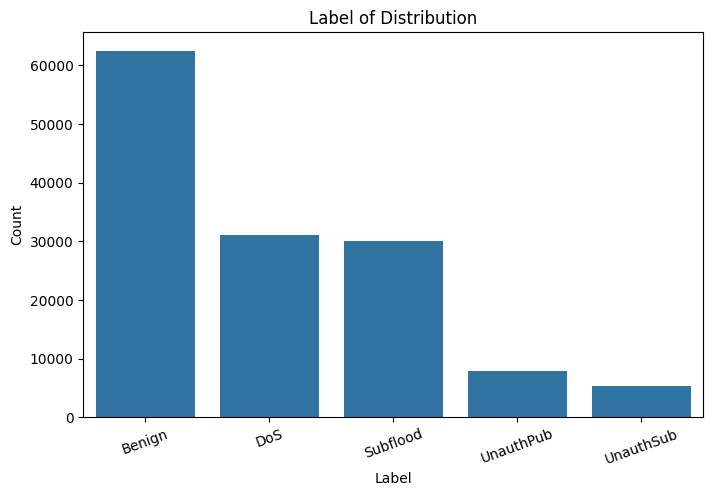

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Label", order=df["Label"].value_counts().index)

plt.title("Label of Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

In [15]:
df["Label"].value_counts(normalize=True).mul(100).round(2)

,proportion
Label,
Benign,45.73
DoS,22.68
Subflood,22.00
UnauthPub,5.72
UnauthSub,3.87


# **Obejct Column**

In [16]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
  print(f"{col}")
  # print("Unique Values: ", df[col].nunique())
  # print(df[col].head(3))

Flow ID
Src IP
Dst IP
Timestamp
Label


In [17]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("No of Numerical Features: ", len(numeric_cols))
print("Infinity Values: ", np.isinf(df[numeric_cols]).sum().sum())
print("Zero Variance Number: ", (df[numeric_cols].nunique() <= 1).sum())

No of Numerical Features:  79
Infinity Values:  278
Zero Variance Number:  14


In [18]:
zero_variance_cols = numeric_cols[df[numeric_cols].nunique() <= 1]
print("Zero Variance Cols: ", zero_variance_cols.tolist())

Zero Variance Cols:  ['Fwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Fwd Seg Size Min']


In [19]:
inf_count = pd.Series(
    np.isinf(df[numeric_cols]).sum(),
    index=numeric_cols
)
print("Infinity Values: \n", inf_count[inf_count > 0])

Infinity Values: 
 Flow Byts/s      3
Flow Pkts/s    275
dtype: int64


In [20]:
df_clean = df.drop(columns=zero_variance_cols).copy()

df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Flow Byts/s    275
Flow Pkts/s    275
dtype: int64


In [21]:
df_clean = df_clean.dropna()

print("New Shape: ", df_clean.shape)
print("Missing Values: ", df_clean.isnull().sum().sum())

New Shape:  (136406, 70)
Missing Values:  0


# **Data Pre-Processing**

In [22]:
exclude_cols = [
"Flow ID",
"Src IP",
"Dst IP",
"Timestamp",
"Label"
]

X = df_clean.drop(columns=exclude_cols)
y = df_clean["Label"]

print("X Shape: ", X.shape)
print("y shape: ", y.shape)

X Shape:  (136406, 65)
y shape:  (136406,)


In [23]:
print("Features: ", X.count().sum().sum())

Features:  8866390


# **Level Encoder**

In [24]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
print("Classes: ", label_encoder.classes_)
print("Encoded: ", np.unique(y_encoded))

Classes:  ['Benign' 'DoS' 'Subflood' 'UnauthPub' 'UnauthSub']
Encoded:  [0 1 2 3 4]


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify = y_encoded

)
print("Trainig: ", X_train.shape, y_train.shape)
print("Testing: ", X_test.shape, y_test.shape)

Trainig:  (109124, 65) (109124,)
Testing:  (27282, 65) (27282,)


# **Scale the Features**

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training: ", X_train_scaled.shape)
print("Scaled testing: ", X_test_scaled.shape)

Scaled training:  (109124, 65)
Scaled testing:  (27282, 65)


In [27]:
X_train_scaled.mean()

np.float64(-3.883759881548878e-18)

In [28]:
X_train_scaled.std()

np.float64(0.9999999999999998)

# **Machine Learning Model**

## ***01. Random Forest***

In [29]:
rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    n_jobs = -1
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [30]:
rf_pred = rf.predict(X_test)
rf_prob =rf.predict_proba(X_test)[:,1]

In [37]:
print("Accuracy Score: ", accuracy_score(y_test, rf_pred))
print("Precision Score: ", precision_score(y_test, rf_pred, average="macro"))
print("Recall Score: ", recall_score(y_test, rf_pred, average="macro"))
print("F1 Score: ", f1_score(y_test, rf_pred, average="macro"))
print("Roc Auc Score: ", roc_auc_score(y_test, rf_prob, multi_class='ovr', average='macro'))
print("\n")
print(classification_report(y_test, rf_pred))
print("\n")
print(confusion_matrix(y_test, rf_pred))

Accuracy Score:  0.9770178139432593
Precision Score:  0.9566770959332178
Recall Score:  0.9550542022394513
F1 Score:  0.9558418803413649
Roc Auc Score:  0.993877841223991


              precision    recall  f1-score   support

           0       0.97      0.98      0.98     12457
           1       1.00      1.00      1.00      6200
           2       0.99      0.98      0.98      6013
           3       0.92      0.93      0.92      1563
           4       0.90      0.89      0.90      1049

    accuracy                           0.98     27282
   macro avg       0.96      0.96      0.96     27282
weighted avg       0.98      0.98      0.98     27282



[[12198     0    65   123    71]
 [    1  6198     1     0     0]
 [  131     0  5873     1     8]
 [   92     0     0  1451    20]
 [  101     0     6     7   935]]


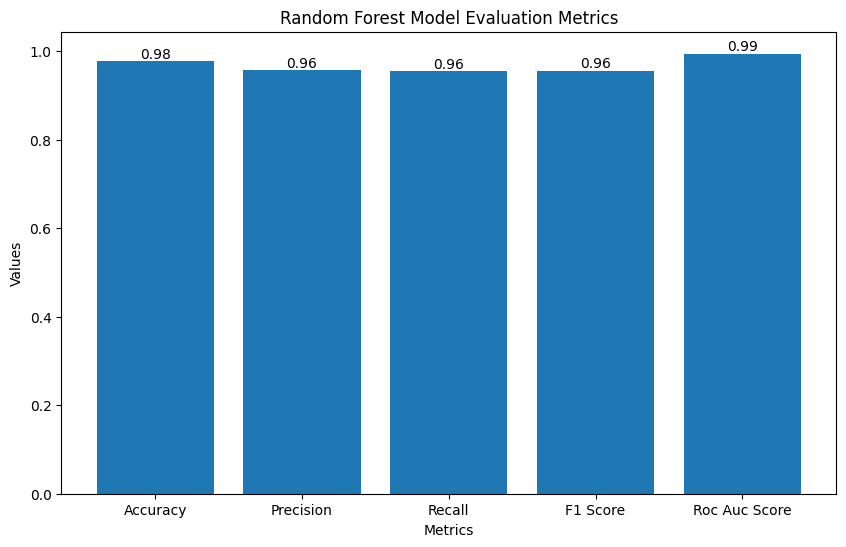

In [32]:
plt.figure(figsize=(10,6))

plt.title("Random Forest Model Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Values")

matrics = ["Accuracy", "Precision", "Recall", "F1 Score", "Roc Auc Score"]
values = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred, average="macro"),
    recall_score(y_test, rf_pred, average="macro"),
    f1_score(y_test, rf_pred, average="macro"),
    roc_auc_score(y_test, rf_prob, multi_class='ovr', average='macro')
]

bars = plt.bar(matrics, values)
plt.bar_label(bars, fmt='%.2f')
plt.show()

## ***02. Logistic Regression***

In [34]:
lg = LogisticRegression(random_state=42, max_iter=1000)
lg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [38]:
lg_pred = lg.predict(X_test_scaled)

lg_prob = lg.predict_proba(X_test_scaled)

In [39]:
print("Accuracy Score: ", accuracy_score(y_test, lg_pred))
print("Precision Score: ", precision_score(y_test, lg_pred, average="macro"))
print("Recall Score: ", recall_score(y_test, lg_pred, average="macro"))
print("F1 Score: ", f1_score(y_test, lg_pred, average="macro"))
print("Roc Auc Score: ", roc_auc_score(y_test, lg_prob, multi_class='ovr', average='macro'))
print("\n")
print(classification_report(y_test, lg_pred))
print("\n")
print(confusion_matrix(y_test, lg_pred))

Accuracy Score:  0.9318598343229968
Precision Score:  0.9082440110152155
Recall Score:  0.7939375316309564
F1 Score:  0.830494776843852
Roc Auc Score:  0.9735214162319329


              precision    recall  f1-score   support

           0       0.89      0.98      0.93     12457
           1       1.00      1.00      1.00      6200
           2       0.98      0.96      0.97      6013
           3       0.87      0.39      0.53      1563
           4       0.80      0.65      0.72      1049

    accuracy                           0.93     27282
   macro avg       0.91      0.79      0.83     27282
weighted avg       0.93      0.93      0.92     27282



[[12175     2    87    67   126]
 [    1  6198     0     0     1]
 [  234     0  5768    10     1]
 [  918     0     1   602    42]
 [  347     0     7    15   680]]


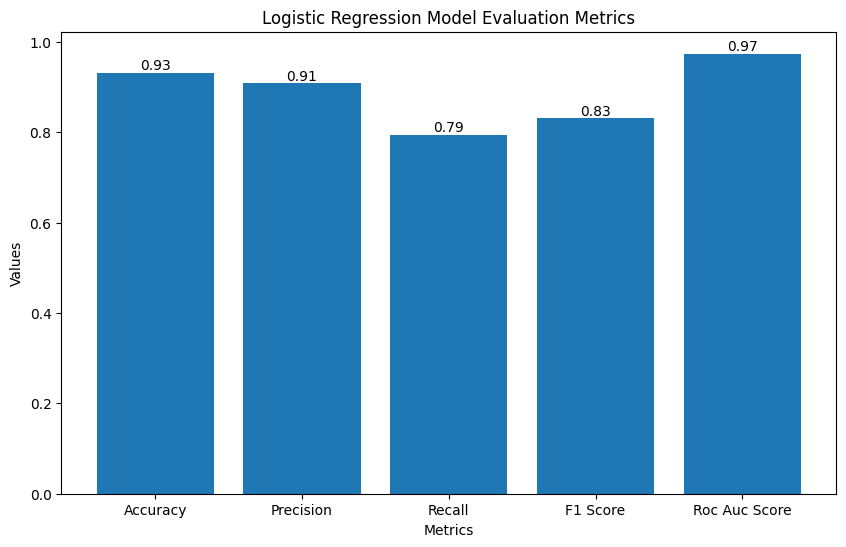

In [40]:
plt.figure(figsize=(10,6))

plt.title("Logistic Regression Model Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Values")

matrics = ["Accuracy", "Precision", "Recall", "F1 Score", "Roc Auc Score"]
values = [
    accuracy_score(y_test, lg_pred),
    precision_score(y_test, lg_pred, average="macro"),
    recall_score(y_test, lg_pred, average="macro"),
    f1_score(y_test, lg_pred, average="macro"),
    roc_auc_score(y_test, lg_prob, multi_class='ovr', average='macro')
]

bars = plt.bar(matrics, values)
plt.bar_label(bars, fmt='%.2f')
plt.show()

## ***03. K-Nearest Neighbors***

In [41]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [42]:
knn_pred = knn.predict(X_test_scaled)

In [43]:
knn_prob = knn.predict_proba(X_test_scaled)

In [45]:
print("Accuracy Score: ", accuracy_score(y_test, knn_pred))
print("Precision Score: ", precision_score(y_test, knn_pred, average="macro"))
print("Recall Score: ", recall_score(y_test, knn_pred, average="macro"))
print("F1 Score: ", f1_score(y_test, knn_pred, average="macro"))
print("Roc Auc Score: ", roc_auc_score(y_test, knn_prob, multi_class='ovr', average='macro'))
print("\n")
print(classification_report(y_test, knn_pred))
print("\n")
print(confusion_matrix(y_test, knn_pred))

Accuracy Score:  0.9718862253500477
Precision Score:  0.9460375747437391
Recall Score:  0.9325374265681738
F1 Score:  0.9390778043140088
Roc Auc Score:  0.9867489248599159


              precision    recall  f1-score   support

           0       0.97      0.98      0.97     12457
           1       1.00      1.00      1.00      6200
           2       0.99      0.98      0.98      6013
           3       0.91      0.90      0.91      1563
           4       0.86      0.81      0.84      1049

    accuracy                           0.97     27282
   macro avg       0.95      0.93      0.94     27282
weighted avg       0.97      0.97      0.97     27282



[[12198     0    82    82    95]
 [    2  6198     0     0     0]
 [  141     0  5864     5     3]
 [  119     0     2  1407    35]
 [  152     0     2    47   848]]


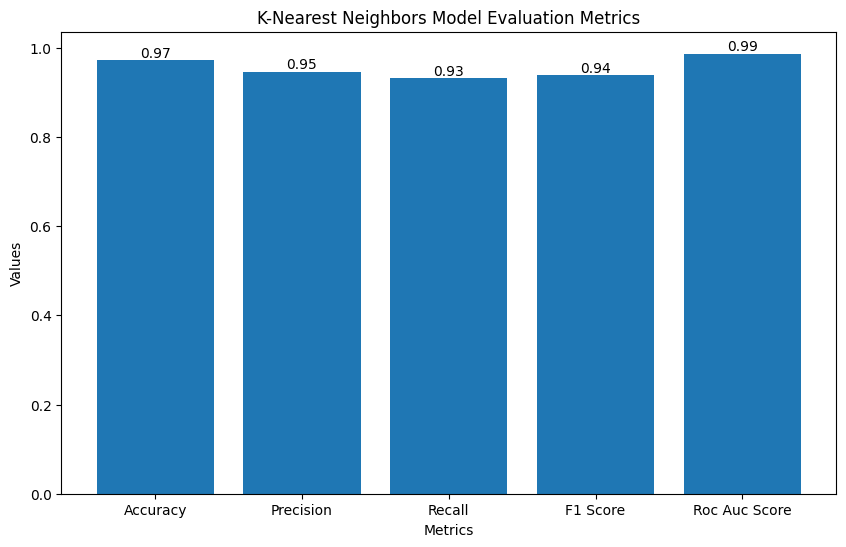

In [46]:
plt.figure(figsize=(10,6))

plt.title("K-Nearest Neighbors Model Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Values")

matrics = ["Accuracy", "Precision", "Recall", "F1 Score", "Roc Auc Score"]
values = [
    accuracy_score(y_test, knn_pred),
    precision_score(y_test, knn_pred, average="macro"),
    recall_score(y_test, knn_pred, average="macro"),
    f1_score(y_test, knn_pred, average="macro"),
    roc_auc_score(y_test, knn_prob, multi_class='ovr', average='macro')
]

bars = plt.bar(matrics, values)
plt.bar_label(bars, fmt='%.2f')
plt.show()

## ***04. Decision Tree***

In [48]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [49]:
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)

In [50]:
print("Accuracy Score: ", accuracy_score(y_test, dt_pred))
print("Precision Score: ", precision_score(y_test, dt_pred, average="macro"))
print("Recall Score: ", recall_score(y_test, dt_pred, average="macro"))
print("F1 Score: ", f1_score(y_test, dt_pred, average="macro"))
print("Roc Auc Score: ", roc_auc_score(y_test, dt_prob, multi_class='ovr', average='macro'))
print("\n")
print(classification_report(y_test, dt_pred))
print("\n")
print(confusion_matrix(y_test, dt_pred))

Accuracy Score:  0.9744520196466535
Precision Score:  0.9509291997042952
Recall Score:  0.9531089415552939
F1 Score:  0.9519998027285611
Roc Auc Score:  0.9728472630162825


              precision    recall  f1-score   support

           0       0.97      0.97      0.97     12457
           1       1.00      1.00      1.00      6200
           2       0.98      0.98      0.98      6013
           3       0.93      0.93      0.93      1563
           4       0.87      0.89      0.88      1049

    accuracy                           0.97     27282
   macro avg       0.95      0.95      0.95     27282
weighted avg       0.97      0.97      0.97     27282



[[12130     1   135    84   107]
 [    1  6198     1     0     0]
 [  125     0  5876     2    10]
 [   86     0     3  1451    23]
 [  100     0     3    16   930]]


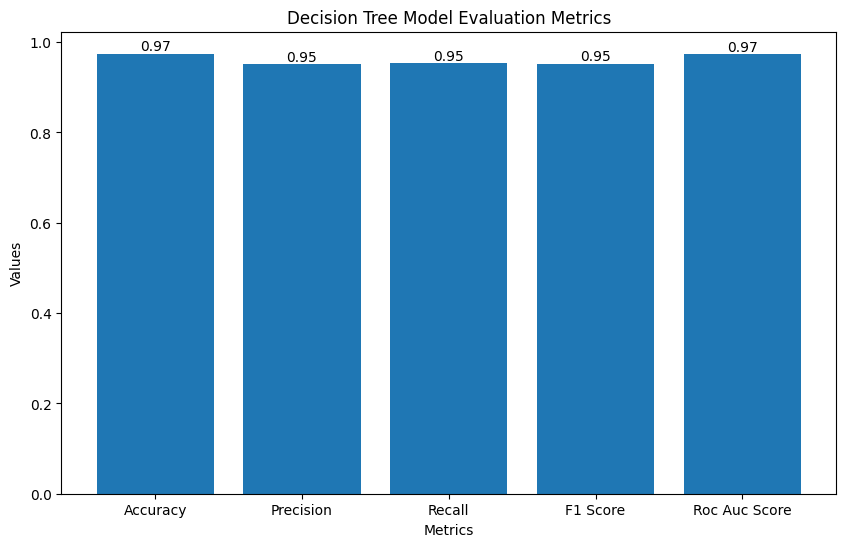

In [51]:
plt.figure(figsize=(10,6))

plt.title("Decision Tree Model Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Values")

matrics = ["Accuracy", "Precision", "Recall", "F1 Score", "Roc Auc Score"]
values = [
    accuracy_score(y_test, dt_pred),
    precision_score(y_test, dt_pred, average="macro"),
    recall_score(y_test, dt_pred, average="macro"),
    f1_score(y_test, dt_pred, average="macro"),
    roc_auc_score(y_test, dt_prob, multi_class='ovr', average='macro')
]

bars = plt.bar(matrics, values)
plt.bar_label(bars, fmt='%.2f')
plt.show()

## ***05. Support Vector Classification***

In [52]:
svc = SVC(probability=True, random_state=42)
svc.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [53]:
svc_pred = svc.predict(X_test_scaled)
svc_prob = svc.predict_proba(X_test_scaled)

In [54]:
print("Accuracy Score: ", accuracy_score(y_test, svc_pred))
print("Precision Score: ", precision_score(y_test, svc_pred, average="macro"))
print("Recall Score: ", recall_score(y_test, svc_pred, average="macro"))
print("F1 Score: ", f1_score(y_test, svc_pred, average="macro"))
print("Roc Auc Score: ", roc_auc_score(y_test, svc_prob, multi_class='ovr', average='macro'))
print("\n")
print(classification_report(y_test, svc_pred))
print("\n")
print(confusion_matrix(y_test, svc_pred))

Accuracy Score:  0.9174180778535298
Precision Score:  0.8818218329996304
Recall Score:  0.7446169732467556
F1 Score:  0.7463188580417921
Roc Auc Score:  0.9769995315638142


              precision    recall  f1-score   support

           0       0.86      0.98      0.92     12457
           1       1.00      1.00      1.00      6200
           2       0.98      0.96      0.97      6013
           3       0.78      0.04      0.08      1563
           4       0.78      0.74      0.76      1049

    accuracy                           0.92     27282
   macro avg       0.88      0.74      0.75     27282
weighted avg       0.91      0.92      0.89     27282



[[12219     0    84     9   145]
 [    1  6198     0     0     1]
 [  243     0  5768     1     1]
 [ 1421     0     1    68    73]
 [  257     0     7     9   776]]


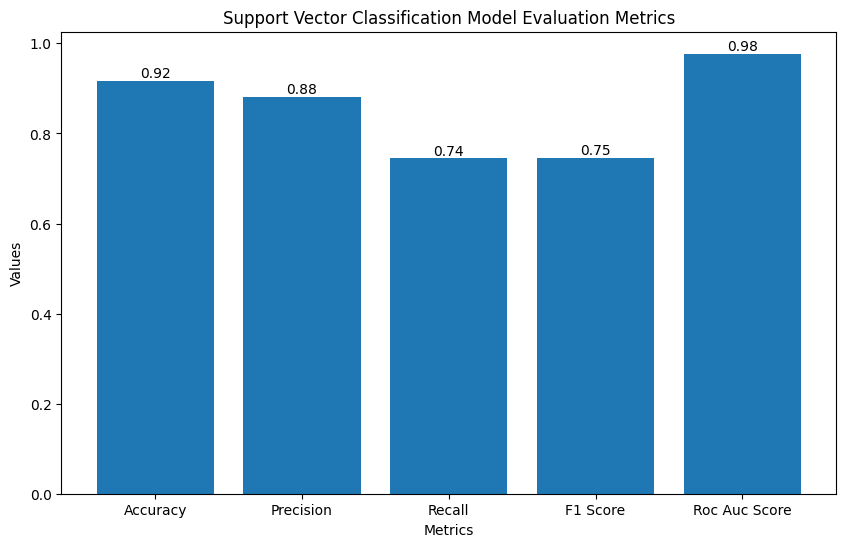

In [55]:
plt.figure(figsize=(10,6))

plt.title("Support Vector Classification Model Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Values")

matrics = ["Accuracy", "Precision", "Recall", "F1 Score", "Roc Auc Score"]
values = [
    accuracy_score(y_test, svc_pred),
    precision_score(y_test, svc_pred, average="macro"),
    recall_score(y_test, svc_pred, average="macro"),
    f1_score(y_test, svc_pred, average="macro"),
    roc_auc_score(y_test, svc_prob, multi_class='ovr', average='macro')
]

bars = plt.bar(matrics, values)
plt.bar_label(bars, fmt='%.2f')
plt.show()

## ***06. AdaBoost Model***

In [58]:
ab = AdaBoostClassifier(random_state=42)
ab.fit(X_train, y_train)

AdaBoostClassifier(random_state=42)

In [59]:
ab_pred = ab.predict(X_test)
ab_prob = ab.predict_proba(X_test)

In [60]:
print("Accuracy Score: ", accuracy_score(y_test, ab_pred))
print("Precision Score: ", precision_score(y_test, ab_pred, average="macro"))
print("Recall Score: ", recall_score(y_test, ab_pred, average="macro"))
print("F1 Score: ", f1_score(y_test, ab_pred, average="macro"))
print("Roc Auc Score: ", roc_auc_score(y_test, ab_prob, multi_class='ovr', average='macro'))
print("\n")
print(classification_report(y_test, ab_pred))
print("\n")
print(confusion_matrix(y_test, ab_pred))

Accuracy Score:  0.9219631991789459
Precision Score:  0.9236194483335934
Recall Score:  0.8038011393613281
F1 Score:  0.8428496216158811
Roc Auc Score:  0.9488429253546802


              precision    recall  f1-score   support

           0       0.87      0.98      0.92     12457
           1       1.00      1.00      1.00      6200
           2       0.98      0.85      0.91      6013
           3       0.91      0.81      0.86      1563
           4       0.86      0.38      0.53      1049

    accuracy                           0.92     27282
   macro avg       0.92      0.80      0.84     27282
weighted avg       0.93      0.92      0.92     27282



[[12184     0   113   122    38]
 [    2  6198     0     0     0]
 [  911     0  5101     1     0]
 [  263     0     1  1273    26]
 [  642     0     7     3   397]]


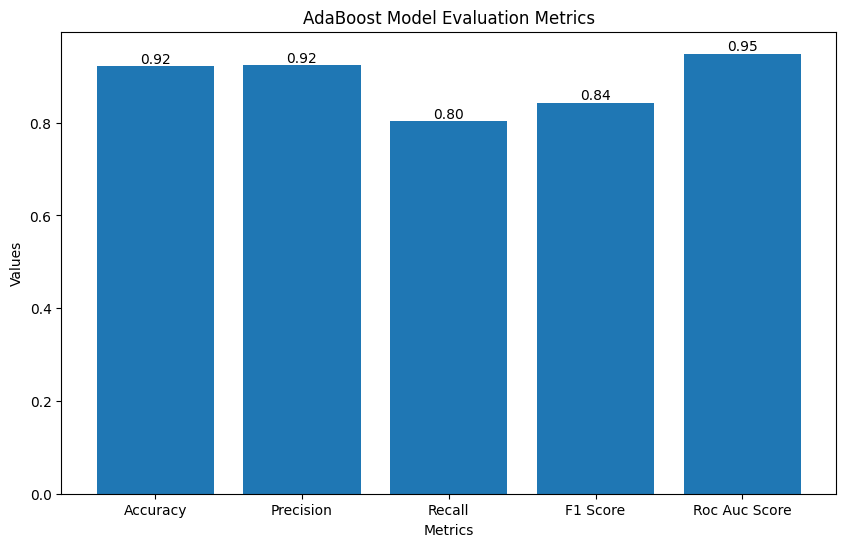

In [61]:
plt.figure(figsize=(10,6))

plt.title("AdaBoost Model Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Values")

matrics = ["Accuracy", "Precision", "Recall", "F1 Score", "Roc Auc Score"]
values = [
    accuracy_score(y_test, ab_pred),
    precision_score(y_test, ab_pred, average="macro"),
    recall_score(y_test, ab_pred, average="macro"),
    f1_score(y_test, ab_pred, average="macro"),
    roc_auc_score(y_test, ab_prob, multi_class='ovr', average='macro')
]

bars = plt.bar(matrics, values)
plt.bar_label(bars, fmt='%.2f')
plt.show()

## ***07. XG Boost Model***

In [62]:
from xgboost import XGBClassifier

In [64]:
xgb = XGBClassifier(
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)

In [65]:
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)

In [66]:
print("Accuracy Score: ", accuracy_score(y_test, xgb_pred))
print("Precision Score: ", precision_score(y_test, xgb_pred, average="macro"))
print("Recall Score: ", recall_score(y_test, xgb_pred, average="macro"))
print("F1 Score: ", f1_score(y_test, xgb_pred, average="macro"))
print("Roc Auc Score: ", roc_auc_score(y_test, xgb_prob, multi_class='ovr', average='macro'))
print("\n")
print(classification_report(y_test, xgb_pred))
print("\n")
print(confusion_matrix(y_test, xgb_pred))

Accuracy Score:  0.9823326735576571
Precision Score:  0.9698293850678519
Recall Score:  0.9627913469174185
F1 Score:  0.9662375106444981
Roc Auc Score:  0.9982125915011976


              precision    recall  f1-score   support

           0       0.98      0.99      0.98     12457
           1       1.00      1.00      1.00      6200
           2       0.99      0.98      0.99      6013
           3       0.94      0.95      0.94      1563
           4       0.94      0.90      0.92      1049

    accuracy                           0.98     27282
   macro avg       0.97      0.96      0.97     27282
weighted avg       0.98      0.98      0.98     27282



[[12287     0    42    80    48]
 [    2  6198     0     0     0]
 [  119     0  5890     1     3]
 [   71     0     0  1478    14]
 [   94     0     0     8   947]]


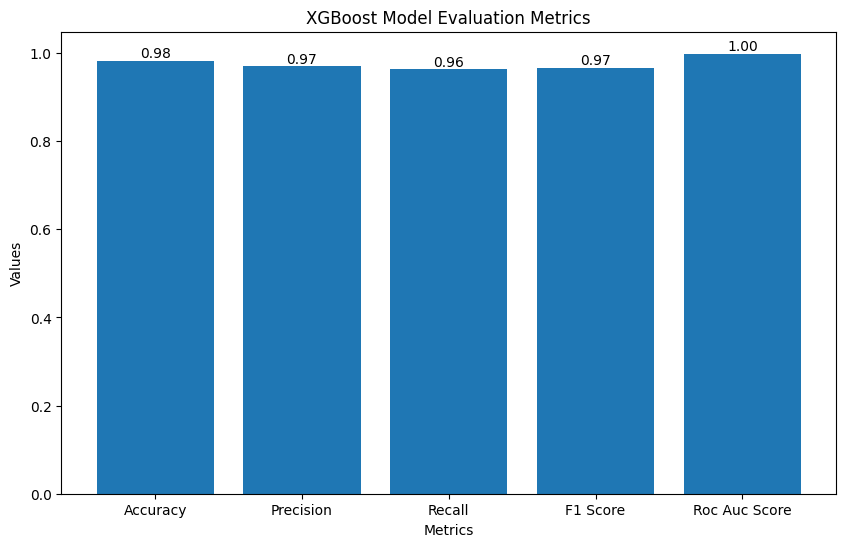

In [67]:
plt.figure(figsize=(10,6))

plt.title("XGBoost Model Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Values")

matrics = ["Accuracy", "Precision", "Recall", "F1 Score", "Roc Auc Score"]
values = [
    accuracy_score(y_test, xgb_pred),
    precision_score(y_test, xgb_pred, average="macro"),
    recall_score(y_test, xgb_pred, average="macro"),
    f1_score(y_test, xgb_pred, average="macro"),
    roc_auc_score(y_test, xgb_prob, multi_class='ovr', average='macro')
]

bars = plt.bar(matrics, values)
plt.bar_label(bars, fmt='%.2f')
plt.show()

## **Comparision of All the ML Model**

In [68]:
model_names = [
    "Random Forest",
    "Logistic Regression",
    "K-Nearest Neighbors",
    "Decision Tree",
    "Support Vector Classification",
    "AdaBoost",
    "XGBoost"
]

accuracy_scores = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, lg_pred),
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, svc_pred),
    accuracy_score(y_test, ab_pred),
    accuracy_score(y_test, xgb_pred)
]

precision_scores = [
    precision_score(y_test, rf_pred, average="macro"),
    precision_score(y_test, lg_pred, average="macro"),
    precision_score(y_test, knn_pred, average="macro"),
    precision_score(y_test, dt_pred, average="macro"),
    precision_score(y_test, svc_pred, average="macro"),
    precision_score(y_test, ab_pred, average="macro"),
    precision_score(y_test, xgb_pred, average="macro")
]

recall_scores = [
    recall_score(y_test, rf_pred, average="macro"),
    recall_score(y_test, lg_pred, average="macro"),
    recall_score(y_test, knn_pred, average="macro"),
    recall_score(y_test, dt_pred, average="macro"),
    recall_score(y_test, svc_pred, average="macro"),
    recall_score(y_test, ab_pred, average="macro"),
    recall_score(y_test, xgb_pred, average="macro")
]

f1_scores = [
    f1_score(y_test, rf_pred, average="macro"),
    f1_score(y_test, lg_pred, average="macro"),
    f1_score(y_test, knn_pred, average="macro"),
    f1_score(y_test, dt_pred, average="macro"),
    f1_score(y_test, svc_pred, average="macro"),
    f1_score(y_test, ab_pred, average="macro"),
    f1_score(y_test, xgb_pred, average="macro")
]

roc_auc_scores = [
    roc_auc_score(y_test, rf_prob, multi_class='ovr', average='macro'),
    roc_auc_score(y_test, lg_prob, multi_class='ovr', average='macro'),
    roc_auc_score(y_test, knn_prob, multi_class='ovr', average='macro'),
    roc_auc_score(y_test, dt_prob, multi_class='ovr', average='macro'),
    roc_auc_score(y_test, svc_prob, multi_class='ovr', average='macro'),
    roc_auc_score(y_test, ab_prob, multi_class='ovr', average='macro'),
    roc_auc_score(y_test, xgb_prob, multi_class='ovr', average='macro')
]


comparison_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracy_scores,
    "Precision": precision_scores,
    "Recall": recall_scores,
    "F1 Score": f1_scores,
    "ROC AUC Score": roc_auc_scores
})

display(comparison_df.set_index('Model'))

,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
Model,,,,,
Random Forest,0.977018,0.956677,0.955054,0.955842,0.993878
Logistic Regression,0.931860,0.908244,0.793938,0.830495,0.973521
K-Nearest Neighbors,0.971886,0.946038,0.932537,0.939078,0.986749
Decision Tree,0.974452,0.950929,0.953109,0.952000,0.972847
Support Vector Classification,0.917418,0.881822,0.744617,0.746319,0.977000
AdaBoost,0.921963,0.923619,0.803801,0.842850,0.948843
XGBoost,0.982333,0.969829,0.962791,0.966238,0.998213


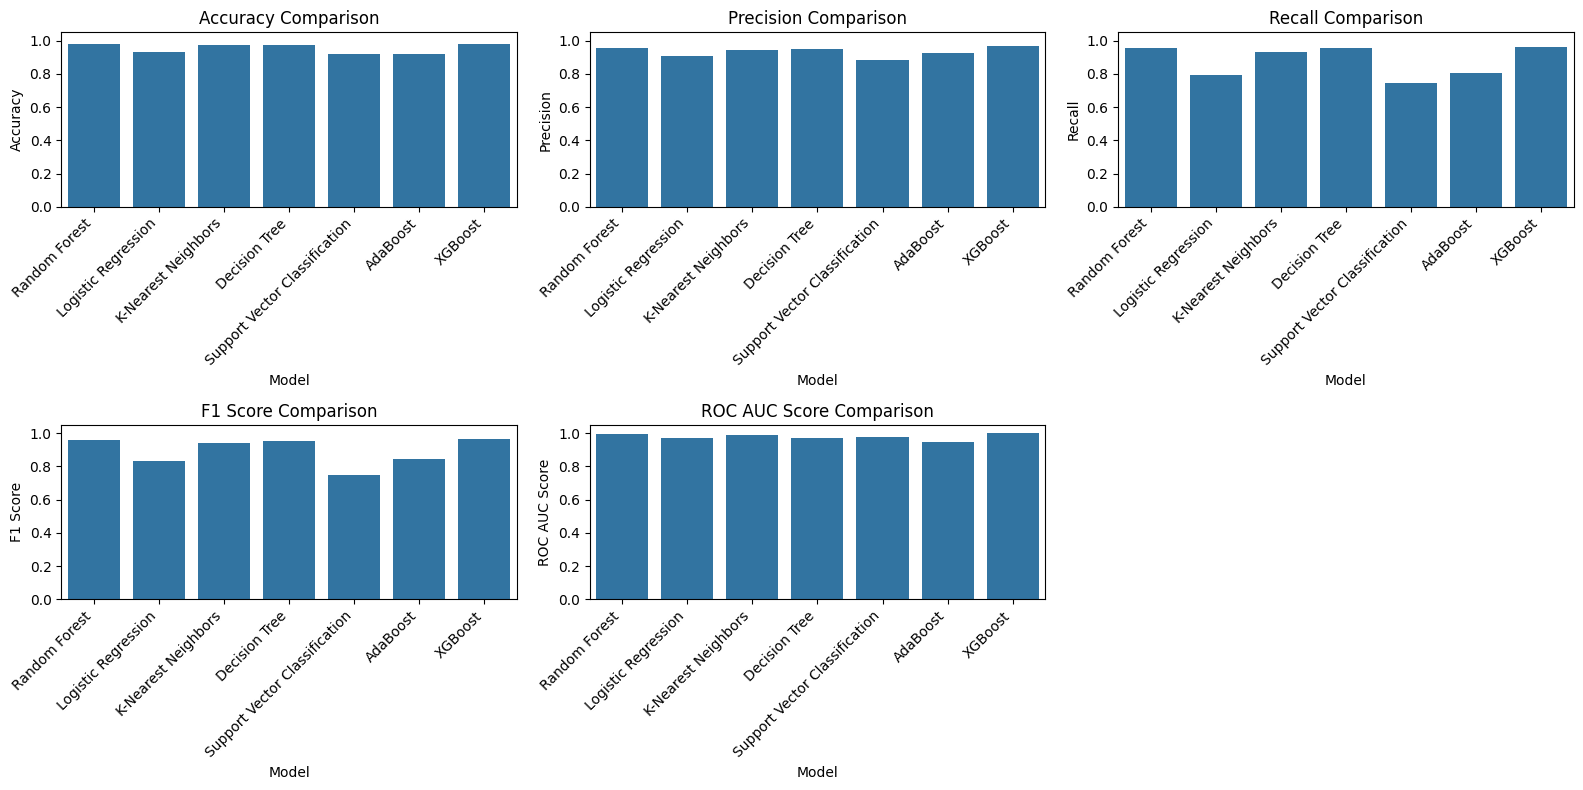

In [69]:
plt.figure(figsize=(16, 8))

# Accuracy
plt.subplot(2, 3, 1)
sns.barplot(x='Model', y='Accuracy', data=comparison_df)
plt.title('Accuracy Comparison')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')

# Precision
plt.subplot(2, 3, 2)
sns.barplot(x='Model', y='Precision', data=comparison_df)
plt.title('Precision Comparison')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')

# Recall
plt.subplot(2, 3, 3)
sns.barplot(x='Model', y='Recall', data=comparison_df)
plt.title('Recall Comparison')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')

# F1 Score
plt.subplot(2, 3, 4)
sns.barplot(x='Model', y='F1 Score', data=comparison_df)
plt.title('F1 Score Comparison')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')

# ROC-AUC Score
plt.subplot(2, 3, 5)
sns.barplot(x='Model', y='ROC AUC Score', data=comparison_df)
plt.title('ROC AUC Score Comparison')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

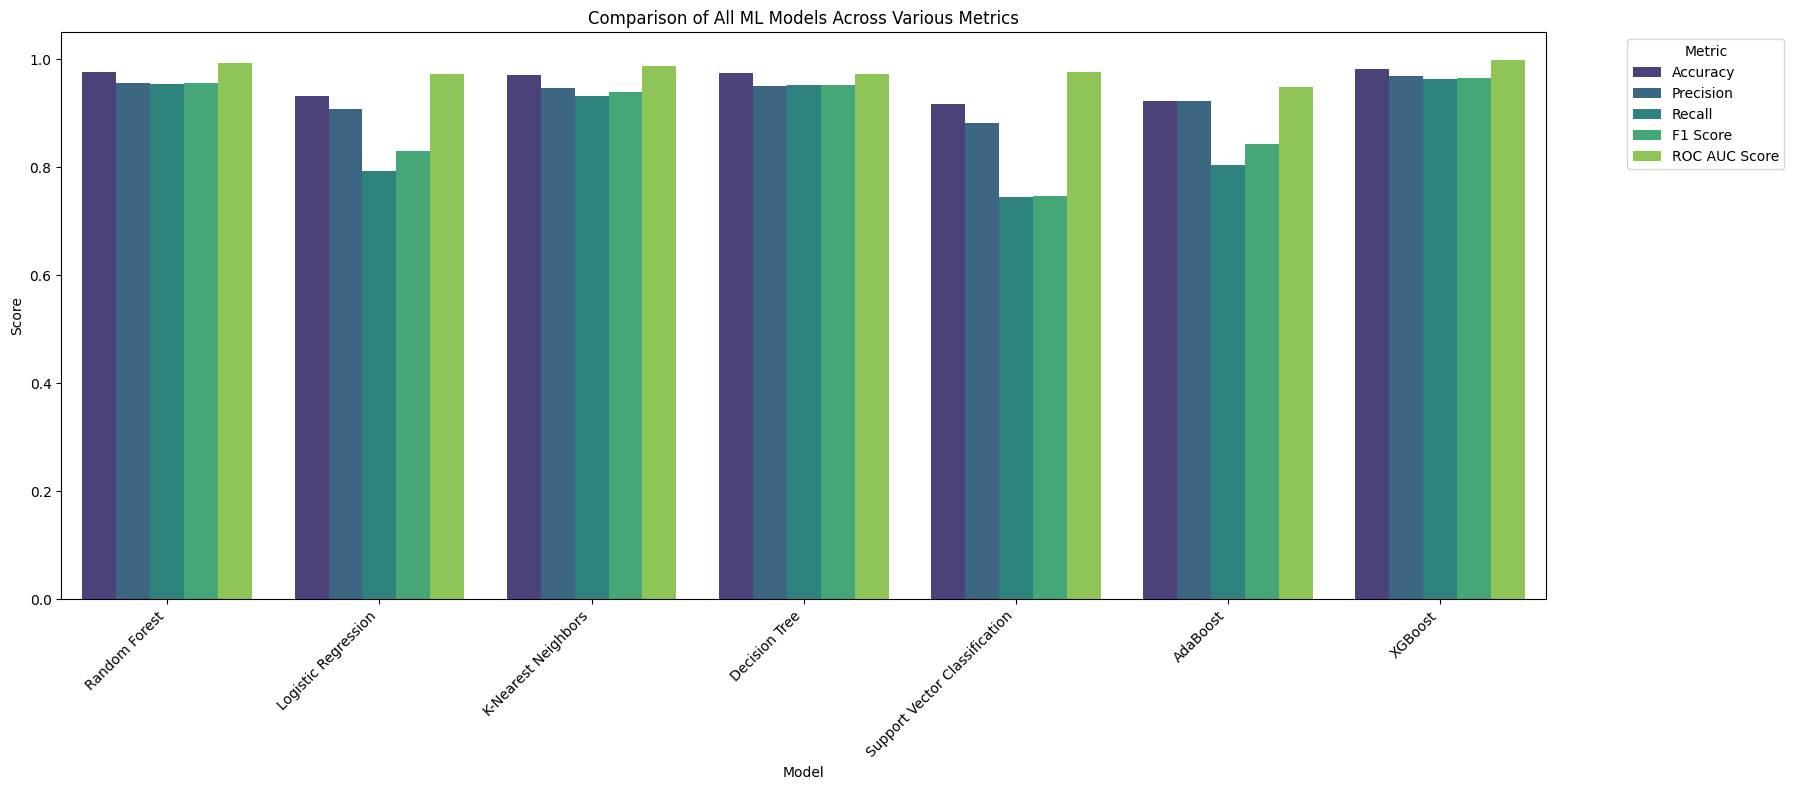

In [70]:
df_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(18, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='viridis')
plt.title('Comparison of All ML Models Across Various Metrics')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

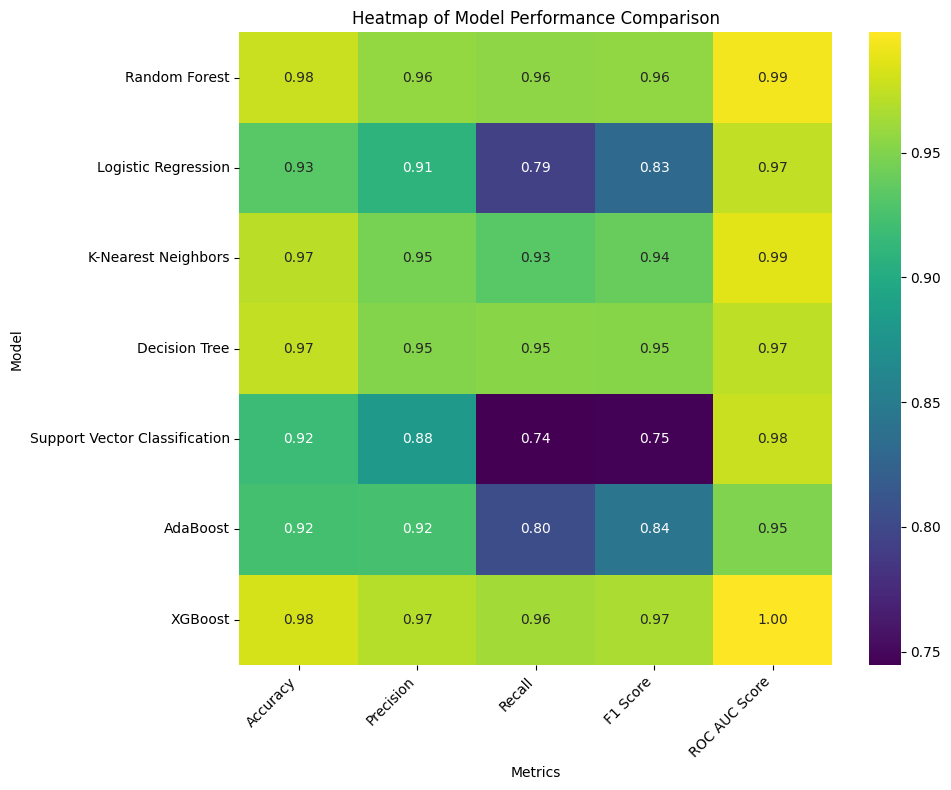

In [71]:
plt.figure(figsize=(10, 8))
sns.heatmap(comparison_df.set_index('Model'), annot=True, cmap='viridis', fmt=".2f")
plt.title('Heatmap of Model Performance Comparison')
plt.xlabel('Metrics')
plt.ylabel('Model')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()